# Capture & Validate GNSS Sample

Single notebook to: capture a 10s sample from the u-blox EVK-F9P, assess its health for FineSat, and preview the processed signal.

In [1]:
# ── Config ──
PORT = "/dev/cu.usbmodem11301"
BAUD = 115200
DURATION_SEC = 10
RATE_HZ = 10
TARGET_EPOCHS = DURATION_SEC * RATE_HZ  # 100

SPEED_OF_LIGHT = 299_792_458.0
MS_TO_METERS = SPEED_OF_LIGHT / 1000.0

# POLY_ORDER = 10
POLY_ORDER = 3
SMOOTHING_WINDOW = 5        # 0.5s at 10 Hz
CYCLE_SLIP_THRESH = 50.0    # meters
MIN_REF_ELEV = 45           # degrees (soft threshold)

CONSTELLATION_MAP = {"1077": "GPS", "1127": "BDS"}
ACCEPTED_SIGNALS  = {"1077": {"1C"}, "1127": {"2I", "1X"}}
NAV_GNSS_MAP      = {0: "GPS", 3: "BDS"}

SAMPLE_LABEL = "push"  # change before each capture
SAMPLE_DIR = "samples"

## 1. Capture

In [71]:
import time
import sys
import io
import serial

print(f"Recording {DURATION_SEC}s from {PORT} @ {BAUD}")
print(f"Label: {SAMPLE_LABEL}")
print()

for i in range(3, 0, -1):
    print(f"Starting in {i}...")
    time.sleep(1)

print("GO!")

raw_buffer = io.BytesIO()

with serial.Serial(PORT, BAUD, timeout=1) as ser:
    start = time.time()
    while True:
        elapsed = time.time() - start
        if elapsed > DURATION_SEC:
            break
        chunk = ser.read(ser.in_waiting or 1)
        if chunk:
            raw_buffer.write(chunk)
        sys.stdout.write(f"\rRecording... {elapsed:.1f}s / {DURATION_SEC}s")
        sys.stdout.flush()

raw_buffer.seek(0)
print(f"\n\nCaptured {raw_buffer.getbuffer().nbytes / 1024:.1f} KB")

Recording 10s from /dev/cu.usbmodem11301 @ 115200
Label: push

Starting in 3...
Starting in 2...
Starting in 1...
GO!
Recording... 10.0s / 10s

Captured 39.7 KB


## 2. Parse

In [10]:
raw_buffer =open("/Users/tushar/s/wifi2sat/gnss-data-collection/samples/push-260430-102650.rtcm", "rb")

In [11]:
import numpy as np
from pyubx2 import UBXReader
from collections import defaultdict

def _key(constellation, prn):
    return f"{constellation}_{int(prn):03d}"

def parse_sample(buf):
    """Single-pass parse: elevations, carrier phases (meters), message counts."""
    buf.seek(0)
    elevations = {}
    phases = defaultdict(list)
    msg_counts = defaultdict(int)

    ubr = UBXReader(buf)
    for _raw, parsed in ubr:
        if parsed is None:
            continue
        mid = parsed.identity
        msg_counts[mid] += 1

        # NAV-SAT -> elevations
        if mid == "NAV-SAT":
            for i in range(1, getattr(parsed, "numSvs", 0) + 1):
                g = getattr(parsed, f"gnssId_{i:02d}", -1)
                s = getattr(parsed, f"svId_{i:02d}", 0)
                e = getattr(parsed, f"elev_{i:02d}", -91)
                c = NAV_GNSS_MAP.get(g)
                if c and e != -91:
                    elevations[_key(c, s)] = e

        # RTCM 1077/1127 -> carrier phase
        elif mid in CONSTELLATION_MAP:
            constellation = CONSTELLATION_MAP[mid]
            accepted = ACCEPTED_SIGNALS[mid]
            n_sat = getattr(parsed, "NSat", 0)
            n_cell = getattr(parsed, "NCell", 0)
            if n_sat == 0 or n_cell == 0:
                continue

            rough = {}
            for s in range(1, n_sat + 1):
                prn = getattr(parsed, f"PRN_{s:02d}", None)
                rr = getattr(parsed, f"DF398_{s:02d}", None)
                if prn is not None and rr is not None:
                    rough[prn] = rr
                    #df397 = getattr(parsed, f"DF397_{s:02d}", None)
                    #rr = getattr(parsed, f"DF398_{s:02d}", None)
                    #if prn is not None and rr is not None and df397 is not None:
                    #    rough[prn] = df397 + rr   # full rough range in ms

            for c in range(1, n_cell + 1):
                prn = getattr(parsed, f"CELLPRN_{c:02d}", None)
                sig = getattr(parsed, f"CELLSIG_{c:02d}", None)
                fpr = getattr(parsed, f"DF406_{c:02d}", None)
                if prn is None or fpr is None or prn not in rough:
                    continue
                if sig not in accepted:
                    continue
                phases[_key(constellation, prn)].append(
                    (rough[prn] + fpr) * MS_TO_METERS
                )

    return elevations, dict(phases), dict(msg_counts)

elevations, phases, msg_counts = parse_sample(raw_buffer)
print(f"Parsed: {sum(msg_counts.values())} messages, {len(phases)} satellite tracks")

Parsed: 210 messages, 15 satellite tracks


## 3. Health Report

In [12]:
# ── message check ──
n_nav = msg_counts.get("NAV-SAT", 0)
n_gps = msg_counts.get("1077", 0)
n_bds = msg_counts.get("1127", 0)

print("Message Counts")
print(f"  NAV-SAT : {n_nav}")
print(f"  RTCM 1077 (GPS)   : {n_gps}")
print(f"  RTCM 1127 (BeiDou): {n_bds}")
print()

# ── per-satellite health table ──
good_sats = []  # (key, elevation)

print(f"{'Satellite':>12}  {'Epochs':>6}  {'Elev':>5}  {'Slips':>5}  Status")
print("-" * 55)

for k in sorted(phases.keys()):
    n = len(phases[k])
    arr = np.array(phases[k][:TARGET_EPOCHS]) if n >= TARGET_EPOCHS else np.array(phases[k])
    slips = int(np.sum(np.abs(np.diff(arr)) > CYCLE_SLIP_THRESH)) if n >= 2 else 0
    elev = elevations.get(k, None)
    elev_str = f"{elev:.0f}" if elev is not None else "?"

    enough = n >= TARGET_EPOCHS
    clean = slips == 0
    ok = enough and clean

    reasons = []
    if not enough:
        reasons.append(f"short ({n}/{TARGET_EPOCHS})")
    if not clean:
        reasons.append(f"{slips} cycle slip(s)")
    status = ", ".join(reasons) if reasons else "ok"
    marker = "pass" if ok else "FAIL"

    print(f"{k:>12}  {n:>6}  {elev_str:>5}  {slips:>5}  {marker:4}  {status}")

    if ok:
        good_sats.append((k, elev if elev is not None else -91))

# ── verdict ──
good_sats.sort(key=lambda x: x[1], reverse=True)
n_good = len(good_sats)
best_elev = good_sats[0][1] if good_sats else -91

print()
print(f"Usable satellites: {n_good}")

issues = []
if n_nav == 0:
    issues.append("No NAV-SAT messages (no elevation data)")
if n_gps == 0 and n_bds == 0:
    issues.append("No RTCM carrier phase messages at all")
if n_good < 2:
    issues.append(f"Need >= 2 usable satellites, got {n_good}")
if n_good >= 2 and best_elev < MIN_REF_ELEV:
    issues.append(f"Best reference elevation is only {best_elev} deg (want >= {MIN_REF_ELEV})")

sample_healthy = n_good >= 2 and (n_gps > 0 or n_bds > 0)

if issues:
    for i in issues:
        severity = "warning" if (sample_healthy) else "BLOCKER"
        print(f"  [{severity}] {i}")

print()
if sample_healthy:
    ref = good_sats[0][0]
    print(f"PASS  |  ref={ref} ({good_sats[0][1]} deg)  |  {n_good - 1} target(s)")
else:
    print("FAIL  |  Sample not usable for FineSat. Move closer to a window or go outdoors.")

Message Counts
  NAV-SAT : 10
  RTCM 1077 (GPS)   : 100
  RTCM 1127 (BeiDou): 100

   Satellite  Epochs   Elev  Slips  Status
-------------------------------------------------------
     BDS_013     100     16     99  FAIL  99 cycle slip(s)
     BDS_023      22      6     21  FAIL  short (22/100), 21 cycle slip(s)
     BDS_027      18     75      0  FAIL  short (18/100)
     BDS_028     100     43      0  pass  ok
     BDS_036     100     11     99  FAIL  99 cycle slip(s)
     BDS_037     100     54      0  pass  ok
     GPS_003     100     14      0  pass  ok
     GPS_006      81     83      1  FAIL  short (81/100), 1 cycle slip(s)
     GPS_011      72     40     71  FAIL  short (72/100), 71 cycle slip(s)
     GPS_012      72     12     71  FAIL  short (72/100), 71 cycle slip(s)
     GPS_014     100     38      0  pass  ok
     GPS_017     100     42      0  pass  ok
     GPS_019     100     62      0  pass  ok
     GPS_022     100     54      0  pass  ok
     GPS_024     100     33  

## 4. Preview FineSat Signal

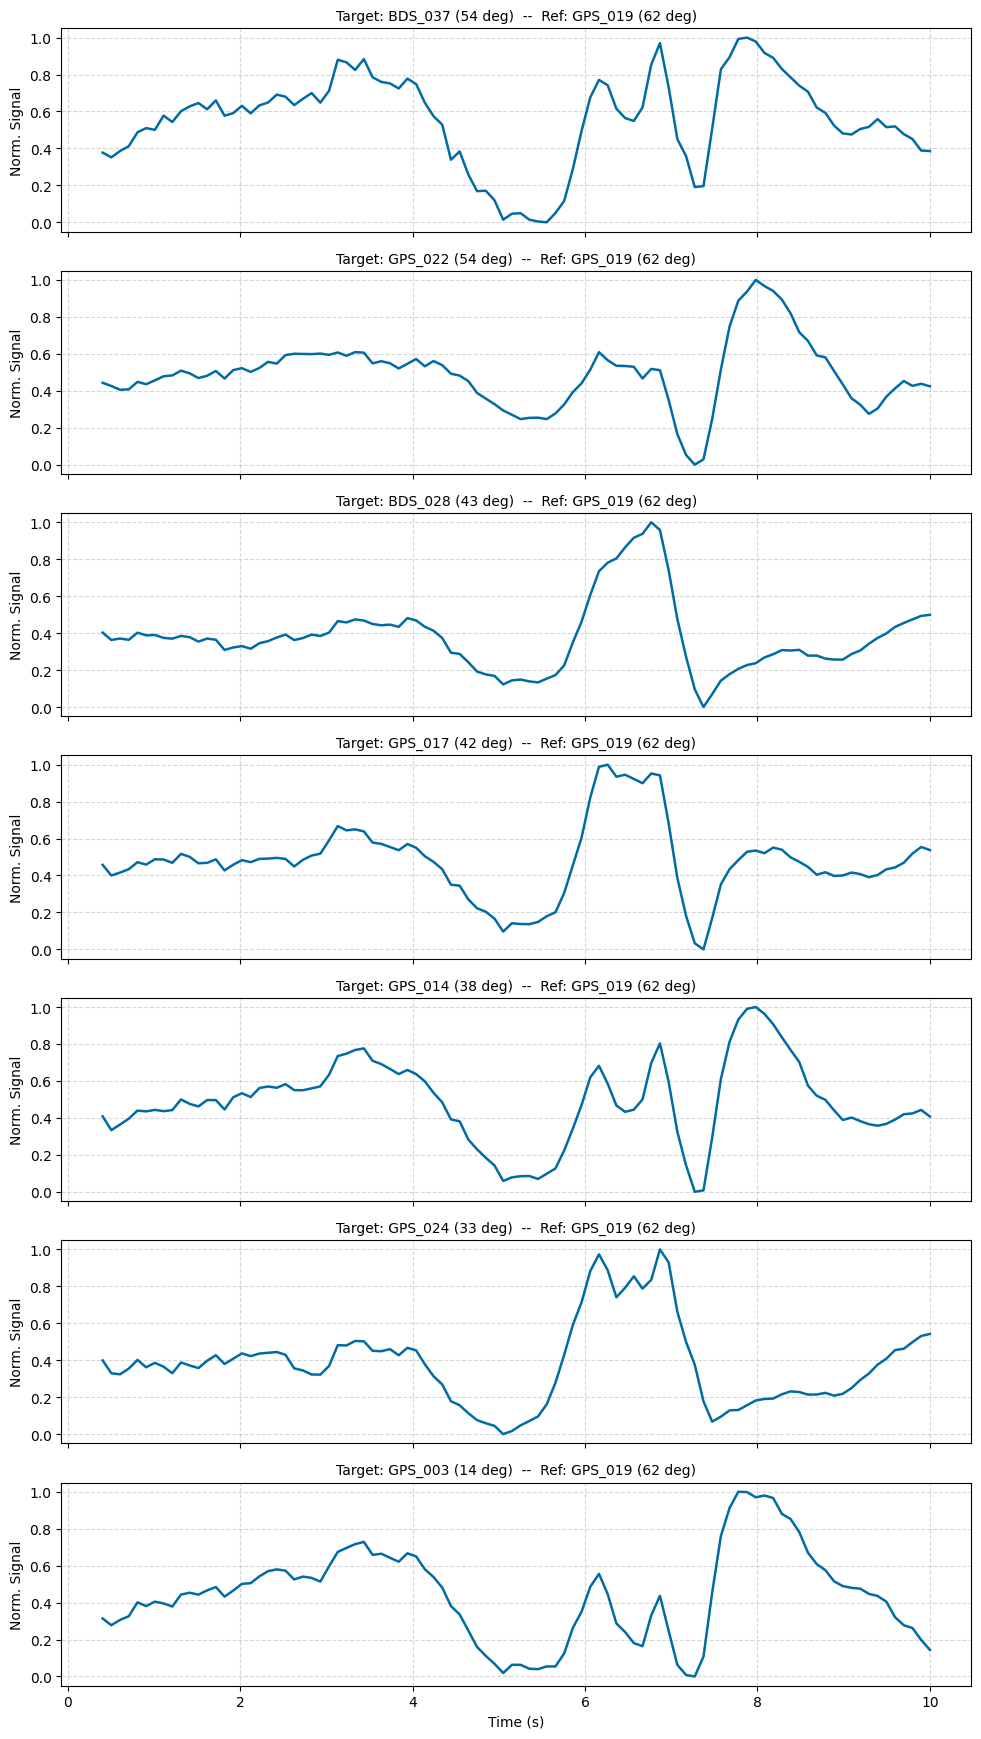

In [13]:
import matplotlib.pyplot as plt
import warnings
try:
    from numpy.exceptions import RankWarning
except ImportError:
    from numpy import RankWarning
warnings.simplefilter("ignore", RankWarning)

if not sample_healthy:
    print("Sample failed health check -- skipping preview.")
else:
    # Build valid arrays (truncated to TARGET_EPOCHS)
    valid = {}
    for k, elev in good_sats:
        valid[k] = np.array(phases[k][:TARGET_EPOCHS])

    ref_key = good_sats[0][0]
    target_keys = [k for k, _ in good_sats[1:]]

    t = np.linspace(0, DURATION_SEC, TARGET_EPOCHS)

    # Step 1: Satellite movement cancellation (10th-order poly)
    residuals = {}
    for k in valid:
        coeffs = np.polyfit(t, valid[k], POLY_ORDER)
        residuals[k] = valid[k] - np.polyval(coeffs, t)

    # Step 2: Cross-satellite differential (cancels receiver clock bias)
    finesat = {}
    for tgt in target_keys:
        diff = residuals[tgt] - residuals[ref_key]
        # Smoothing: 0.5s moving average
        smoothed = np.convolve(diff, np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW, mode="valid")
        s_min, s_max = smoothed.min(), smoothed.max()
        if s_max - s_min < 1e-15:
            finesat[tgt] = np.zeros_like(smoothed)
        else:
            finesat[tgt] = (smoothed - s_min) / (s_max - s_min)

    t_smooth = t[SMOOTHING_WINDOW - 1:]

    # Plot
    n_plots = len(finesat)
    fig, axes = plt.subplots(n_plots, 1, figsize=(10, 2.5 * n_plots), sharex=True, squeeze=False)

    for ax, (tgt, sig) in zip(axes.ravel(), finesat.items()):
        elev_tgt = elevations.get(tgt, "?")
        elev_ref = elevations.get(ref_key, "?")
        ax.plot(t_smooth, sig, color="#006BA4", linewidth=1.8)
        ax.set_ylabel("Norm. Signal")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"Target: {tgt} ({elev_tgt} deg)  --  Ref: {ref_key} ({elev_ref} deg)", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.5)

    axes[-1, 0].set_xlabel("Time (s)")
    # fig.suptitle(f"FineSat Preview: {SAMPLE_LABEL}", fontsize=12, fontweight="bold")
    fig.tight_layout()
    plt.show()

## 5. Save

In [70]:
import os
from datetime import datetime

if not sample_healthy:
    print("Sample failed health check -- not saving. Re-capture.")
else:
    os.makedirs(SAMPLE_DIR, exist_ok=True)
    timestamp = datetime.now().strftime("%y%m%d-%H%M%S") 
    filename = f"{SAMPLE_LABEL}-{timestamp}.rtcm"
    filepath = os.path.join(SAMPLE_DIR, filename)

    raw_buffer.seek(0)
    with open(filepath, "wb") as f:
        f.write(raw_buffer.read())

    print(f"Saved: {filepath}  ({os.path.getsize(filepath) / 1024:.1f} KB)")

Saved: samples/push-260430-102650.rtcm  (39.8 KB)
